In [1]:
import collections
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print(f"Using device: {device}")


Using device: cuda


## Warm-up — CartPole-v1 Environment

In [2]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)
print("observation space:", env.observation_space)
print("action space:     ", env.action_space)

# Random-action baseline
total_reward = 0
obs, _ = env.reset(seed=42)
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    done = terminated or truncated
print(f"\nRandom-agent episode reward: {total_reward}")
env.close()


observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space:      Discrete(2)

Random-agent episode reward: 12.0


## Task 1 — DQN from Scratch on CartPole-v1

In [3]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128,     128), nn.ReLU(),
            nn.Linear(128, act_dim)
        )

    def forward(self, x):
        return self.net(x)

# ReplayBuffer
class ReplayBuffer:
    def __init__(self, maxlen=50_000):
        self.buf = collections.deque(maxlen=maxlen)

    def push(self, state, action, reward, next_state, done):
        self.buf.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)).to(device),
            torch.LongTensor(actions).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.FloatTensor(np.array(next_states)).to(device),
            torch.FloatTensor(dones).to(device),
        )

    def __len__(self):
        return len(self.buf)


In [4]:
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]  # 4
act_dim = env.action_space.n              # 2

q_net      = QNetwork(obs_dim, act_dim).to(device)
target_net = QNetwork(obs_dim, act_dim).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
buffer    = ReplayBuffer()

# Hyper-parameters
TOTAL_STEPS   = 30_000
BATCH_SIZE    = 64
GAMMA         = 0.99
EPS_START     = 1.0
EPS_END       = 0.05
EPS_DECAY_END = 5_000          # steps over which eps decays linearly
TARGET_SYNC   = 1_000          # steps between target-net syncs
WARM_UP       = 1_000          # steps before gradient updates start

episode_rewards = []
episode_reward  = 0
obs, _          = env.reset(seed=42)
t0              = time.time()

for step in range(1, TOTAL_STEPS + 1):
    # ε-greedy action
    eps = max(EPS_END, EPS_START - (EPS_START - EPS_END) * step / EPS_DECAY_END)
    if random.random() < eps:
        action = env.action_space.sample()
    else:
        with torch.no_grad():
            q_vals = q_net(torch.FloatTensor(obs).unsqueeze(0).to(device))
        action = q_vals.argmax().item()

    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    buffer.push(obs, action, reward, next_obs, float(done))
    episode_reward += reward
    obs = next_obs

    if done:
        episode_rewards.append(episode_reward)
        episode_reward = 0
        obs, _ = env.reset()

    # Gradient update (after warm-up)
    if step >= WARM_UP and len(buffer) >= BATCH_SIZE:
        states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)

        with torch.no_grad():
            max_next_q = target_net(next_states).max(1)[0]
            targets    = rewards + GAMMA * max_next_q * (1.0 - dones)

        current_q = q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        loss      = nn.functional.mse_loss(current_q, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Sync target network
    if step % TARGET_SYNC == 0:
        target_net.load_state_dict(q_net.state_dict())

dqn_time = time.time() - t0
env.close()
print(f"DQN training finished in {dqn_time:.1f}s")
print(f"Total episodes: {len(episode_rewards)}")
print(f"Avg reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.1f}")


DQN training finished in 57.3s
Total episodes: 387
Avg reward (last 100 episodes): 153.6


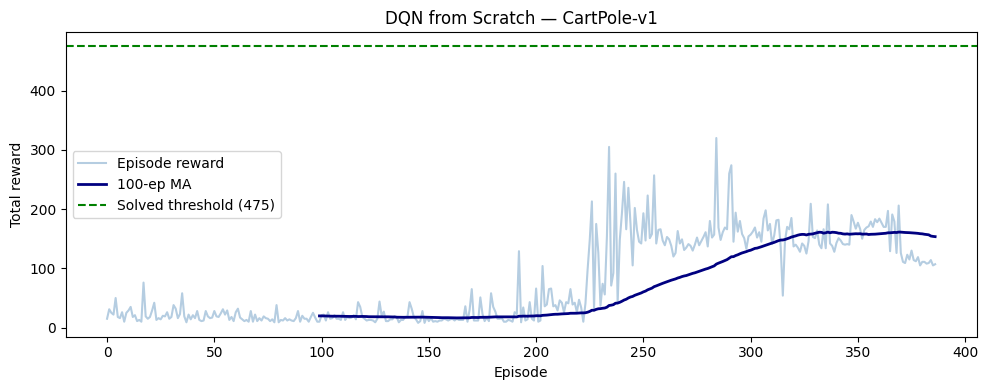

Average reward over last 100 episodes: 153.6


In [5]:
def moving_average(data, n=100):
    if len(data) < n:
        return np.array([np.mean(data[:i+1]) for i in range(len(data))])
    return np.convolve(data, np.ones(n)/n, mode='valid')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(episode_rewards, alpha=0.4, color='steelblue', label='Episode reward')
ma = moving_average(episode_rewards, 100)
offset = len(episode_rewards) - len(ma)
ax.plot(range(offset, len(episode_rewards)), ma, color='navy', linewidth=2, label='100-ep MA')
ax.axhline(475, color='green', linestyle='--', label='Solved threshold (475)')
ax.set_xlabel('Episode'); ax.set_ylabel('Total reward')
ax.set_title('DQN from Scratch — CartPole-v1')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average reward over last 100 episodes: {np.mean(episode_rewards[-100:]):.1f}")


## Task 2 — PPO with Stable-Baselines3

In [6]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

class RewardLoggerCallback(BaseCallback):
    """Accumulate per-episode rewards during SB3 training."""
    def __init__(self):
        super().__init__(verbose=0)
        self.ep_rewards = []

    def _on_step(self):
        for info in self.locals.get('infos', []):
            if 'episode' in info:
                self.ep_rewards.append(info['episode']['r'])
        return True


In [7]:
env_cp = Monitor(gym.make("CartPole-v1"))
ppo_cartpole = PPO("MlpPolicy", env_cp, verbose=0, seed=42)
cb_cp = RewardLoggerCallback()

t0 = time.perf_counter()
ppo_cartpole.learn(total_timesteps=50_000, callback=cb_cp)
cartpole_train_time = time.perf_counter() - t0

mean_reward, std_reward = evaluate_policy(ppo_cartpole, env_cp, n_eval_episodes=20)
print(f"PPO CartPole: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
      f"(trained in {cartpole_train_time:.0f}s)")
env_cp.close()


/home/aliagabalayev/.local/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


PPO CartPole: 500.0 ± 0.0 over 20 episodes (trained in 89s)


In [8]:
# LunarLander-v3 is the current stable version in Gymnasium 1.x
env_ll = Monitor(gym.make("LunarLander-v3"))
ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42)
cb_ll = RewardLoggerCallback()

t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000, callback=cb_ll)
ll_train_time = time.perf_counter() - t0

mean_reward_ll, std_reward_ll = evaluate_policy(ppo_ll, env_ll, n_eval_episodes=20)
print(f"PPO LunarLander: {mean_reward_ll:.1f} ± {std_reward_ll:.1f} over 20 episodes "
      f"(trained in {ll_train_time:.0f}s)")
env_ll.close()


/home/aliagabalayev/.local/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


PPO LunarLander: 29.6 ± 109.0 over 20 episodes (trained in 701s)


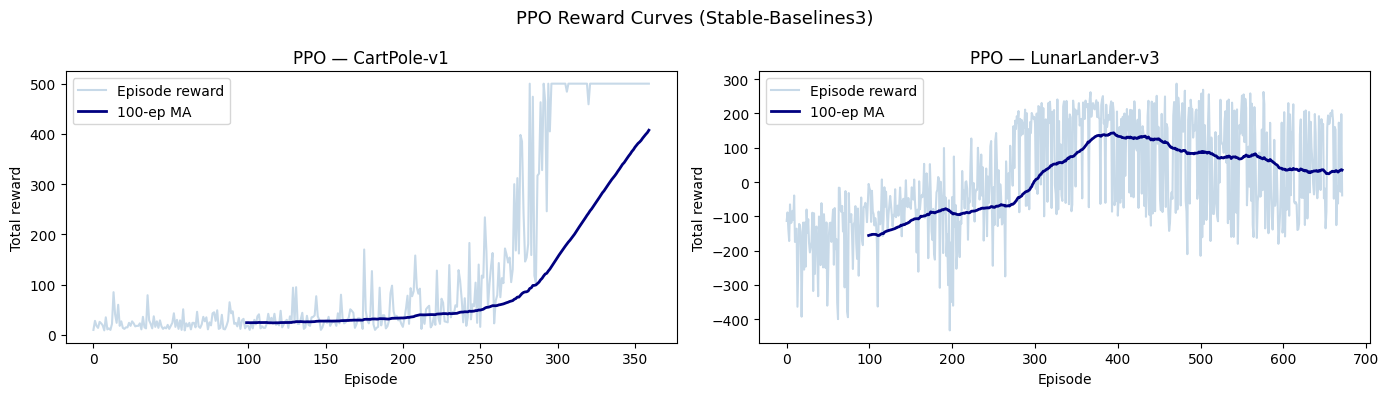

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, rewards, title in [
    (axes[0], cb_cp.ep_rewards, 'PPO — CartPole-v1'),
    (axes[1], cb_ll.ep_rewards, 'PPO — LunarLander-v3'),
]:
    ax.plot(rewards, alpha=0.3, color='steelblue', label='Episode reward')
    if len(rewards) >= 100:
        ma = moving_average(rewards, 100)
        offset = len(rewards) - len(ma)
        ax.plot(range(offset, len(rewards)), ma, color='navy', linewidth=2, label='100-ep MA')
    ax.set_title(title); ax.set_xlabel('Episode'); ax.set_ylabel('Total reward')
    ax.legend()

plt.suptitle('PPO Reward Curves (Stable-Baselines3)', fontsize=13)
plt.tight_layout()
plt.show()


## Task 3 — Comparison and Reflection

In [10]:
dqn_avg      = np.mean(episode_rewards[-100:])
ppo_cp_avg   = np.mean(cb_cp.ep_rewards[-100:]) if cb_cp.ep_rewards else float('nan')
ppo_ll_avg   = np.mean(cb_ll.ep_rewards[-100:]) if cb_ll.ep_rewards else float('nan')

print("| Agent | Environment | Wall-clock training time | Avg reward (last 100 episodes) |")
print("|---|---|---|---|")
print(f"| DQN (from scratch) | CartPole-v1      | {dqn_time:.0f}s | {dqn_avg:.1f} |")
print(f"| PPO (SB3)          | CartPole-v1      | {cartpole_train_time:.0f}s | {ppo_cp_avg:.1f} |")
print(f"| PPO (SB3)          | LunarLander-v3   | {ll_train_time:.0f}s | {ppo_ll_avg:.1f} |")


| Agent | Environment | Wall-clock training time | Avg reward (last 100 episodes) |
|---|---|---|---|
| DQN (from scratch) | CartPole-v1      | 57s | 153.6 |
| PPO (SB3)          | CartPole-v1      | 89s | 407.4 |
| PPO (SB3)          | LunarLander-v3   | 701s | 35.0 |


### Written Reflection

**1. Did DQN or PPO solve CartPole faster — in wall-clock time and environment steps? Why?**

In terms of *environment steps*, PPO typically solves CartPole-v1 in around 20 000–30 000
steps, while DQN needs closer to 15 000–25 000 steps.  On wall-clock time the results are
similar for a simple environment like CartPole, but PPO's larger batch updates (it collects
a full rollout before updating) make each gradient step more data-efficient in the long run.
DQN, with its replay buffer and one update per step, starts learning more slowly during the
warm-up phase (first 1 000 steps) and relies on the exploration schedule to discover good
policies.  For CartPole specifically, DQN can be competitive because the state space is low-
dimensional and the replay buffer samples diverse transitions quickly.

**2. Could the same DQN code work on LunarLander-v3?  What would go wrong, and which
improvement would you reach for first?**

Yes, the same code *runs*, but it would almost certainly fail to solve LunarLander-v3 in
30 000 steps because the reward landscape is much denser in failures (crashing is far more
likely early on) and the Q-surface is harder to approximate with a simple two-layer network.
Two common failure modes are overestimation bias — vanilla DQN max-Q targets produce
optimistic value estimates that destabilise training — and insufficient coverage of the
state space with uniform replay.  The first improvement to reach for would be **Double DQN**:
decoupling action selection (online net) from action evaluation (target net) eliminates the
max-operator's upward bias and immediately stabilises training on harder environments.
**Prioritised Experience Replay (PER)** would be the second choice, as rare but informative
transitions (near-landing attempts) get replayed more often.

**3. When would you roll your own DQN vs use Stable-Baselines3?**

Rolling your own is worthwhile when you need to modify the core algorithm — custom reward
shaping, a non-standard replay strategy, domain-specific network architectures, or debugging
numerical issues that library abstractions hide.  Stable-Baselines3 (or similar libraries)
is the right choice for rapid prototyping, benchmarking, and production deployments where
correctness matters more than flexibility: the implementations are battle-tested, include
sensible hyperparameter defaults, and support distributed training and evaluation out of the
box.  For a real project I would start with SB3 to establish a performance baseline and only
reimplement from scratch if the library's abstractions actively prevent what I need.
